#Load the student data

In [2]:
import pandas as pd
df=pd.read_csv('student_performance.csv')

In [3]:
df.isnull().any()

,0
student_id,False
name,False
age,False
gender,False
department,False
semester,False
math_score,False
science_score,False
english_score,False
programming_score,False


In [4]:
df.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
department,0
semester,0
math_score,0
science_score,0
english_score,0
programming_score,0


In [5]:
df.head(5)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [6]:
print("number of rows and columns: ",df.shape)

number of rows and columns:  (30, 13)


In [7]:
print("number of rows: ",df.shape[0])
print("number of columns: ",df.shape[1])

number of rows:  30
number of columns:  13


In [8]:
df.columns.tolist()

['student_id',
 'name',
 'age',
 'gender',
 'department',
 'semester',
 'math_score',
 'science_score',
 'english_score',
 'programming_score',
 'attendance_percentage',
 'city',
 'admission_year']

In [9]:
print(df.describe())

        student_id        age  semester  math_score  science_score  \
count    30.000000  30.000000      30.0   30.000000      30.000000   
mean   1015.500000  19.733333       2.0   76.066667      77.833333   
std       8.803408   0.739680       0.0   11.467896       8.554423   
min    1001.000000  19.000000       2.0   56.000000      61.000000   
25%    1008.250000  19.000000       2.0   67.250000      71.250000   
50%    1015.500000  20.000000       2.0   75.500000      78.000000   
75%    1022.750000  20.000000       2.0   85.750000      83.750000   
max    1030.000000  21.000000       2.0   95.000000      93.000000   

       english_score  programming_score  attendance_percentage  admission_year  
count      30.000000          30.000000              30.000000            30.0  
mean       74.166667          67.600000              84.500000          2023.0  
std        10.003735          21.041175               9.379913             0.0  
min        55.000000          38.000000      

In [10]:
print(df.dtypes)

student_id                int64
name                     object
age                       int64
gender                   object
department               object
semester                  int64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
attendance_percentage     int64
city                     object
admission_year            int64
dtype: object


#Explore the  student data

ETL -TRANSFORM DATA CLEANING

---



In [11]:
df=df.dropna()

In [12]:
df=df.drop_duplicates()

In [13]:
df['total_score'] = df['math_score'] + df['programming_score']+df['english_score']+df['science_score']

In [14]:
df['average_score']=df['total_score']/4

In [15]:
print("total score: \n",df[['name','total_score']])
print("average score: \n",df[['name','average_score']])

total score: 
               name  total_score
0     Aarav Sharma          326
1      Priya Patel          325
2      Rohit Verma          255
3      Sneha Reddy          273
4       Arjun Nair          356
5      Meera Joshi          246
6      Kiran Kumar          247
7      Divya Singh          356
8     Rahul Mishra          236
9       Ananya Das          371
10     Vikram Iyer          295
11     Pooja Gupta          262
12      Suresh Rao          334
13   Kavya Nambiar          285
14     Ajay Tiwari          280
15    Ritu Agarwal          325
16    Manoj Pandey          210
17  Swati Kulkarni          354
18  Deepak Chauhan          252
19    Nisha Kapoor          327
20   Harish Pillai          259
21     Tanvi Mehta          367
22    Sanjay Dubey          228
23   Preeti Saxena          287
24       Amit Bose          336
25      Rekha Nair          285
26   Gaurav Shukla          325
27   Sunita Pillai          232
28      Nitin Jain          271
29  Akanksha Yadav       

#SQLite Database

In [16]:
import sqlite3
conn=sqlite3.connect('student.db') #Connect Database

In [17]:
df.to_sql("student",conn,if_exists='replace',index=False)

30

5 analysis query

In [18]:
#top 5 student
q1="""select name,total_score from student
order by total_score desc
limit 5"""
pd.read_sql(q1,conn)

,name,total_score
0,Ananya Das,371
1,Tanvi Mehta,367
2,Akanksha Yadav,365
3,Arjun Nair,356
4,Divya Singh,356


In [19]:
#average by department
q2="""select department,avg(total_score) as average_dept_score from student
group by department"""
pd.read_sql(q2,conn)

,department,average_dept_score
0,Civil,235.800000
1,Computer Science,340.153846
2,Electronics,277.500000
3,Mechanical,267.333333


In [20]:
#attendence above 90
q3="""select name,department,attendance_percentage from student where attendance_percentage>90"""
pd.read_sql(q3,conn)

,name,department,attendance_percentage
0,Aarav Sharma,Computer Science,92
1,Sneha Reddy,Mechanical,95
2,Divya Singh,Computer Science,96
3,Ananya Das,Computer Science,98
4,Kavya Nambiar,Mechanical,91
5,Ritu Agarwal,Electronics,93
6,Swati Kulkarni,Computer Science,94
7,Tanvi Mehta,Computer Science,97
8,Amit Bose,Computer Science,91
9,Akanksha Yadav,Computer Science,95


In [21]:
#Highest Programming Score
q4="""select name,department,programming_score from student
order by programming_score desc limit 1"""
pd.read_sql(q4,conn)

,name,department,programming_score
0,Ananya Das,Computer Science,97


In [22]:
#student count by department
q5="""select department, count(*) as student_count from student
group by department"""
pd.read_sql(q5,conn)

,department,student_count
0,Civil,5
1,Computer Science,13
2,Electronics,6
3,Mechanical,6


#Data Visualization

In [24]:
import matplotlib.pyplot as plt

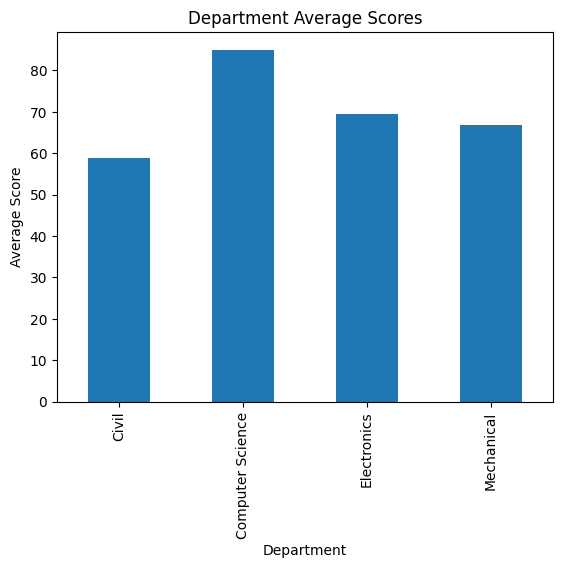

In [25]:
dept_avg = df.groupby("department")["average_score"].mean()

dept_avg.plot(kind="bar")

plt.title("Department Average Scores")
plt.xlabel("Department")
plt.ylabel("Average Score")

plt.show()

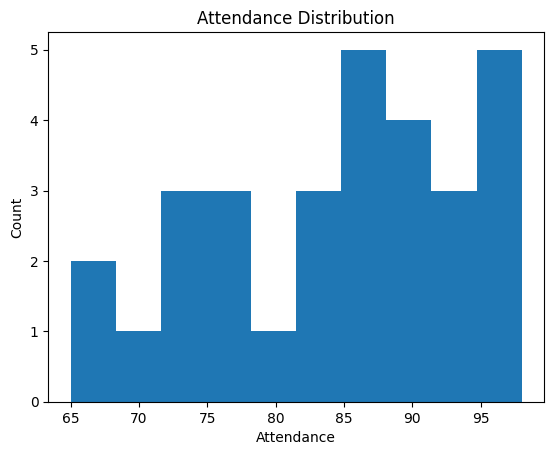

In [27]:
plt.hist(df["attendance_percentage"])

plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Count")

plt.show()

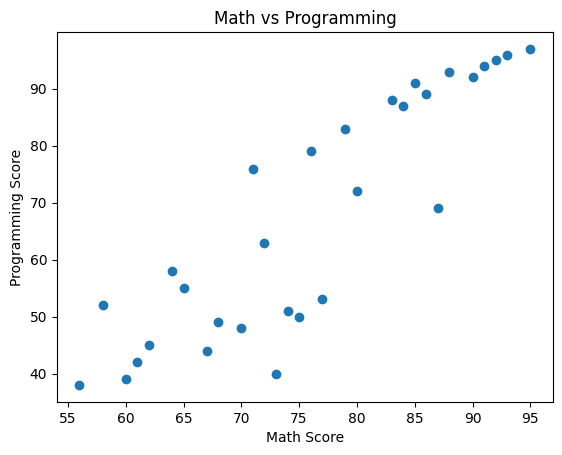

In [28]:
plt.scatter(df["math_score"], df["programming_score"])

plt.xlabel("Math Score")
plt.ylabel("Programming Score")
plt.title("Math vs Programming")

plt.show()

#Machine Learning Prediction

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [30]:
X = df[["math_score", "attendance_percentage"]]
y = df["programming_score"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
predictions = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 9.198333333333332


In [39]:
new_student = [[85, 92]]

predicted_score = model.predict(new_student)

print("Predicted Programming Score:", predicted_score[0])

Predicted Programming Score: 90.07


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


#Business Insights Report

In [40]:
print("BUSINESS INSIGHTS")
print("------------------")

print("1. Students with high attendance score better.")
print("2. CSE department has highest average.")
print("3. Programming score strongly relates to math score.")
print("4. Random Forest predicts student performance effectively.")

BUSINESS INSIGHTS
------------------
1. Students with high attendance score better.
2. CSE department has highest average.
3. Programming score strongly relates to math score.
4. Random Forest predicts student performance effectively.


In [41]:
#save cleaned data
df.to_csv("cleaned_student_data.csv", index=False)

#mini project 2

In [45]:
import pandas as pd

df = pd.read_csv("Project 1 - Weather Dataset.csv")

In [46]:
print(df.head())

       Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0  1/1/2012 0:00    -1.8              -3.9         86                4   
1  1/1/2012 1:00    -1.8              -3.7         87                4   
2  1/1/2012 2:00    -1.8              -3.4         89                7   
3  1/1/2012 3:00    -1.5              -3.2         88                6   
4  1/1/2012 4:00    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa               Weather  
0            8.0     101.24                   Fog  
1            8.0     101.24                   Fog  
2            4.0     101.26  Freezing Drizzle,Fog  
3            4.0     101.27  Freezing Drizzle,Fog  
4            4.8     101.23                   Fog  


In [47]:
print(df.columns)

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')


In [50]:
df.rename(columns={
    'Temp_C':'temperature',
    'Rel Hum_%':'humidity',
    'Wind Speed_km/h':'wind_speed',
    'Weather':'weather'
}, inplace=True)

print("\nUPDATED COLUMNS")
print(df.columns)


UPDATED COLUMNS
Index(['Date/Time', 'temperature', 'Dew Point Temp_C', 'humidity',
       'wind_speed', 'Visibility_km', 'Press_kPa', 'weather'],
      dtype='object')


In [51]:
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

print("\nDATA CLEANED SUCCESSFULLY")


DATA CLEANED SUCCESSFULLY


In [52]:
df["heat_index"] = df["temperature"] + (0.1 * df["humidity"])

print("\nHEAT INDEX COLUMN ADDED")
print(df.head())


HEAT INDEX COLUMN ADDED
       Date/Time  temperature  Dew Point Temp_C  humidity  wind_speed  \
0  1/1/2012 0:00         -1.8              -3.9        86           4   
1  1/1/2012 1:00         -1.8              -3.7        87           4   
2  1/1/2012 2:00         -1.8              -3.4        89           7   
3  1/1/2012 3:00         -1.5              -3.2        88           6   
4  1/1/2012 4:00         -1.5              -3.3        88           7   

   Visibility_km  Press_kPa               weather  heat_index  
0            8.0     101.24                   Fog         6.8  
1            8.0     101.24                   Fog         6.9  
2            4.0     101.26  Freezing Drizzle,Fog         7.1  
3            4.0     101.27  Freezing Drizzle,Fog         7.3  
4            4.8     101.23                   Fog         7.3  


In [53]:
conn = sqlite3.connect("weather.db")

df.to_sql("weather", conn, if_exists="replace", index=False)

print("\nDATA STORED IN SQLITE DATABASE")


DATA STORED IN SQLITE DATABASE


In [54]:
print("\n1. TOP 5 HOTTEST RECORDS")

q1 = """
SELECT temperature, weather
FROM weather
ORDER BY temperature DESC
LIMIT 5
"""

print(pd.read_sql(q1, conn))


1. TOP 5 HOTTEST RECORDS
   temperature       weather
0         33.0  Mainly Clear
1         33.0  Mainly Clear
2         32.9  Mainly Clear
3         32.8         Clear
4         32.7  Mainly Clear


In [55]:
print("\n2. AVERAGE HUMIDITY")

q2 = """
SELECT AVG(humidity) as average_humidity
FROM weather
"""

print(pd.read_sql(q2, conn))


2. AVERAGE HUMIDITY
   average_humidity
0         67.431694


In [56]:
q3 = """
SELECT weather, COUNT(*) as total
FROM weather
GROUP BY weather
ORDER BY total DESC
LIMIT 10
"""

print(pd.read_sql(q3, conn))

         weather  total
0   Mainly Clear   2106
1  Mostly Cloudy   2069
2         Cloudy   1728
3          Clear   1326
4           Snow    390
5           Rain    306
6   Rain Showers    188
7            Fog    150
8       Rain,Fog    116
9    Drizzle,Fog     80


In [57]:
print("\n4. HIGH WIND SPEED RECORDS")

q4 = """
SELECT temperature, wind_speed
FROM weather
WHERE wind_speed > 30
"""

print(pd.read_sql(q4, conn))


4. HIGH WIND SPEED RECORDS
     temperature  wind_speed
0            5.2          35
1            4.6          39
2            3.9          32
3            3.7          33
4            2.9          32
..           ...         ...
434         -3.7          37
435        -11.9          32
436        -12.4          37
437        -11.8          37
438        -11.3          32

[439 rows x 2 columns]


In [58]:
print("\n5. AVERAGE TEMPERATURE BY WEATHER")

q5 = """
SELECT weather,
AVG(temperature) as avg_temperature
FROM weather
GROUP BY weather
LIMIT 10
"""

print(pd.read_sql(q5, conn))


5. AVERAGE TEMPERATURE BY WEATHER
                   weather  avg_temperature
0                    Clear         6.825716
1                   Cloudy         7.970544
2                  Drizzle         7.353659
3              Drizzle,Fog         8.067500
4  Drizzle,Ice Pellets,Fog         0.400000
5             Drizzle,Snow         1.050000
6         Drizzle,Snow,Fog         0.693333
7                      Fog         4.303333
8         Freezing Drizzle        -5.657143
9     Freezing Drizzle,Fog        -2.533333


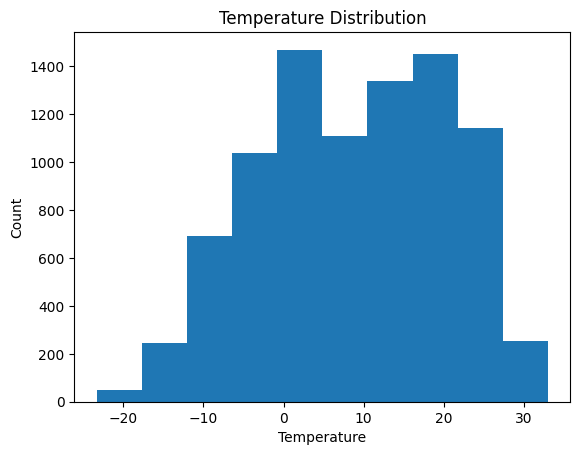

In [59]:
plt.hist(df["temperature"])

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Count")

plt.show()

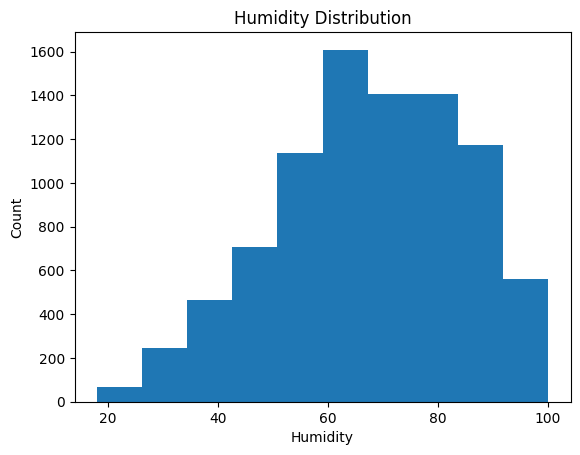

In [60]:
plt.hist(df["humidity"])

plt.title("Humidity Distribution")
plt.xlabel("Humidity")
plt.ylabel("Count")

plt.show()


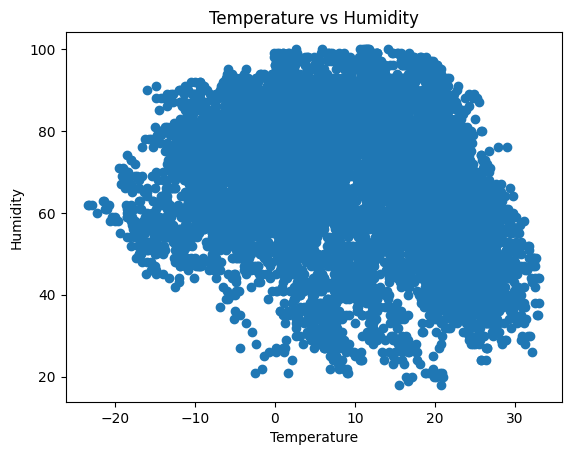

In [61]:
plt.scatter(df["temperature"], df["humidity"])

plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity")

plt.show()

In [62]:
X = df[["temperature", "wind_speed"]]

# Target
y = df["humidity"]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


In [65]:
model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")


MODEL TRAINED SUCCESSFULLY


In [66]:
predictions = model.predict(X_test)

In [67]:
error = mean_absolute_error(y_test, predictions)

print("\nMEAN ABSOLUTE ERROR")
print(error)


MEAN ABSOLUTE ERROR
14.06353912663887


In [68]:
new_weather = [[30, 15]]

predicted_humidity = model.predict(new_weather)

print("\nPREDICTED HUMIDITY")
print(predicted_humidity[0])


PREDICTED HUMIDITY
46.395166666666654


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [69]:
print("\n================================")
print("WEATHER BUSINESS INSIGHTS")
print("================================")

print("1. Temperature affects humidity levels.")
print("2. High wind speed changes weather conditions.")
print("3. Most weather records belong to common weather patterns.")
print("4. Random Forest predicts humidity effectively.")
print("5. Heat index increases with humidity.")


WEATHER BUSINESS INSIGHTS
1. Temperature affects humidity levels.
2. High wind speed changes weather conditions.
3. Most weather records belong to common weather patterns.
4. Random Forest predicts humidity effectively.
5. Heat index increases with humidity.


In [70]:
df.to_csv("cleaned_weather_data.csv", index=False)

print("\nCLEANED DATA SAVED SUCCESSFULLY")


CLEANED DATA SAVED SUCCESSFULLY
